# Diffusion Model — CIFAR-10 Cats

Adapted from MNIST digit diffusion. Key changes:
- Dataset: `CIFAR-10` (class 3 = cats)
- Image shape: `(3, 32, 32)` instead of `(1, 28, 28)`
- Targets accessed via `.targets` (tensor, same as MNIST)

In [ ]:
import sys
from pathlib import Path

directorio_padre = str(Path.cwd().parent)

if directorio_padre not in sys.path:
    sys.path.append(directorio_padre)

In [ ]:
import numpy as np
from functools import partial

import torch
from torch.utils.data import (
    DataLoader,
    Dataset,
    Subset,
)
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision.transforms import functional

from diffusion_lib.legacy import diffusion_process as dfp

from diffusion_lib.utils.visualization import (
    plot_image_grid,
    plot_image_evolution,
    plot_image_evolution_rgb,
    animation_images,
)

n_threads = torch.get_num_threads()
print('Number of threads: {:d}'.format(n_threads))

device = 'gpu' if torch.cuda.is_available() else 'mps'

Number of threads: 4


## 1. Load CIFAR-10 and filter cats (class index = 3)

In [ ]:
# CHANGE 1: Use CIFAR10 instead of MNIST
data = datasets.CIFAR10(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()   # images will be float tensors in [0, 1], shape (3, 32, 32)
)

# CHANGE 2: CIFAR-10 class indices
# 0=airplane, 1=automobile, 2=bird, 3=cat, 4=deer,
# 5=dog, 6=frog, 7=horse, 8=ship, 9=truck
CAT_CLASS = 3

# CHANGE 3: .targets in CIFAR10 is a plain Python list, so we convert it first
targets_tensor = torch.tensor(data.targets)
indices_cat = torch.where(targets_tensor == CAT_CLASS)[0]

data_train = Subset(data, indices_cat)
print(type(data_train))
print(f'Number of cat images: {len(data_train)}')

<class 'torch.utils.data.dataset.Subset'>
Number of cat images: 5000


/Users/ivandominguez/Desktop/practicas3segundocuatri/apaut3/proyecto/proyecto_AAIII_02_diffusion_models/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## 2. Visualize a few samples

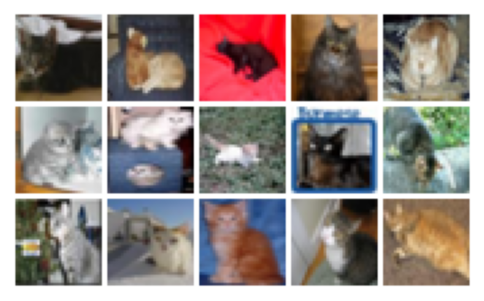

In [4]:
n_rows = 3
n_cols = 5

# Each item is (tensor_3x32x32, label) — we pass the image tensor directly
_ = plot_image_grid(
    images=[data_train[i][0] for i in range(n_rows * n_cols)],
    figsize=(6, 4),   # slightly larger to appreciate RGB detail
    n_rows=n_rows,
    n_cols=n_cols,
)

## 3. Diffusion process (unchanged)

In [5]:
sigma = 25.0

def bm_drift_coefficient(x_t, t):
    """Zero drift — Brownian motion with no deterministic component."""
    return torch.zeros_like(x_t)

def bm_diffusion_coefficient(t, sigma=sigma):
    """Exponentially growing diffusion coefficient."""
    return sigma**t

def bm_mu_t(x_0, t):
    """Mean of the forward process at time t equals the original image."""
    return x_0

def bm_sigma_t(t, sigma=sigma):
    """Standard deviation of the forward process at time t."""
    return torch.sqrt(0.5 * (sigma**(2 * t) - 1.0) / np.log(sigma))

diffusion_process = dfp.GaussianDiffussionProcess(
    drift_coefficient=bm_drift_coefficient,
    diffusion_coefficient=bm_diffusion_coefficient,
    mu_t=bm_mu_t,
    sigma_t=bm_sigma_t,
)

## 4. Score model

> **Note:** `ScoreNet` must accept 3-channel 32×32 inputs.  
> If your original `ScoreNet` was hard-coded for `(1, 28, 28)`, update its first conv layer accordingly (e.g. `in_channels=3`).

In [6]:
from diffusion_lib import UNetScoreModelColor as ScoreNet

# CHANGE 4: If ScoreNet accepts an `in_channels` or `image_size` argument, pass it here.
# Example (adapt to your ScoreNet signature):
#   ScoreNet(marginal_prob_std=..., in_channels=3)
score_model = torch.nn.DataParallel(
    ScoreNet(
        marginal_prob_std=partial(bm_sigma_t, sigma=sigma)
    )
)
score_model = score_model.to(device)

In [7]:
import importlib
import diffusion_lib; sm = type("sm", (), {"ScoreNet": diffusion_lib.UNetScoreModelColor})()
importlib.reload(sm)

from functools import partial

score_model = torch.nn.DataParallel(
    sm.ScoreNet(
        marginal_prob_std=partial(bm_sigma_t, sigma=sigma)
    )
)
score_model = score_model.to(device)

In [8]:
import inspect
print(inspect.getsource(score_model.module.forward))

    def forward(self, x, t):
        embed = self.act(self.embed(t))

        # Encoder
        h1 = self.act(self.gnorm1(self.conv1(x)  + self.dense1(embed)))  # (B, 32, 32, 32)
        h2 = self.act(self.gnorm2(self.conv2(h1) + self.dense2(embed)))  # (B, 64, 16, 16)
        h3 = self.act(self.gnorm3(self.conv3(h2) + self.dense3(embed)))  # (B, 128, 8, 8)
        h4 = self.act(self.gnorm4(self.conv4(h3) + self.dense4(embed)))  # (B, 256, 4, 4)

        # Decoder con skip connections
        h = self.act(self.tgnorm4(self.tconv4(h4) + self.dense5(embed)))              # (B, 128, 8, 8)
        h = self.act(self.tgnorm3(self.tconv3(torch.cat([h, h3], dim=1)) + self.dense6(embed)))  # (B, 64, 16, 16)
        h = self.act(self.tgnorm2(self.tconv2(torch.cat([h, h2], dim=1)) + self.dense7(embed)))  # (B, 32, 32, 32)
        h = self.tconv1(torch.cat([h, h1], dim=1))                                    # (B, 3, 32, 32)

        h = h / self.marginal_prob_std(t)[:, None, None, None]
        re

## 5. Training loop

In [9]:
# from torch.optim import Adam
# import tqdm.notebook

# batch_size = 32

# data_loader = DataLoader(
#     data_train,
#     batch_size=batch_size,
#     shuffle=True,
#     num_workers=n_threads,
# )

# learning_rate = 1.0e-3
# optimizer = Adam(score_model.parameters(), lr=learning_rate)

# n_epochs = 3000
# tqdm_epoch = tqdm.notebook.trange(n_epochs)

# for epoch in tqdm_epoch:
#     avg_loss = 0.0
#     num_items = 0

#     for x, y in data_loader:
#         x = x.to(device)
#         loss = diffusion_process.loss_function(score_model, x)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         avg_loss += loss.item() * x.shape[0]
#         num_items += x.shape[0]

#     tqdm_epoch.set_description('Average Loss: {:5f}'.format(avg_loss / num_items))

# torch.save(score_model.state_dict(), '../other_checkpoints/cifar_cats_{:d}_epochs.pth'.format(n_epochs))

## 6. Generate synthetic cat images

In [10]:
from functools import partial
import torch

n_epochs = 3000
n_images = 3

# CHANGE 6: load the correct checkpoint name
checkpoint_path = '../other_checkpoints/cifar_cats_{:d}_epochs.pth'.format(n_epochs)
check_point = torch.load(checkpoint_path, map_location='cpu')
score_model.load_state_dict(check_point)
score_model = score_model.cpu()


def backward_drift_coefficient(x_t, t, diffusion_coefficient):
    """Reverse-time drift for the probability flow ODE / SDE."""

    # Ensure t is a 1-D tensor with one entry per image in the batch
    if not isinstance(t, torch.Tensor):
        t = torch.tensor([t], device='cpu', dtype=torch.float32)
    if t.dim() == 0 or t.shape[0] != x_t.shape[0]:
        t = t.expand(x_t.shape[0])

    score = score_model(x_t, t)                           # score estimate ∇log p(x_t)
    view_shape = [x_t.shape[0]] + [1] * (x_t.dim() - 1)  # (B, 1, 1, 1) for broadcasting
    g_t = diffusion_coefficient(t).view(*view_shape)      # diffusion coeff at time t

    return -(g_t ** 2) * score                            # reverse-SDE drift term


T = 1.0
t_tensor = torch.tensor([T], device='cpu')
sigma_max = diffusion_process.sigma_t(t_tensor).detach().cpu()

# CHANGE 7: shape is now (n_images, 3, 32, 32) — RGB, 32×32
image_T = torch.randn(n_images, 3, 32, 32, device='cpu') * sigma_max.view(1, 1, 1, 1)

with torch.no_grad():
    times, synthetic_images_t = dfp.euler_maruyama_integrator(
        image_T,
        t_0=T,
        t_end=1.0e-3,
        n_steps=500,
        drift_coefficient=partial(
            backward_drift_coefficient,
            diffusion_coefficient=bm_diffusion_coefficient,
        ),
        diffusion_coefficient=bm_diffusion_coefficient,
    )

score_model = score_model.to(device)

print(type(synthetic_images_t))
print(synthetic_images_t.shape)

<class 'torch.Tensor'>
torch.Size([3, 3, 32, 32, 501])


## 7. Visualize the denoising evolution

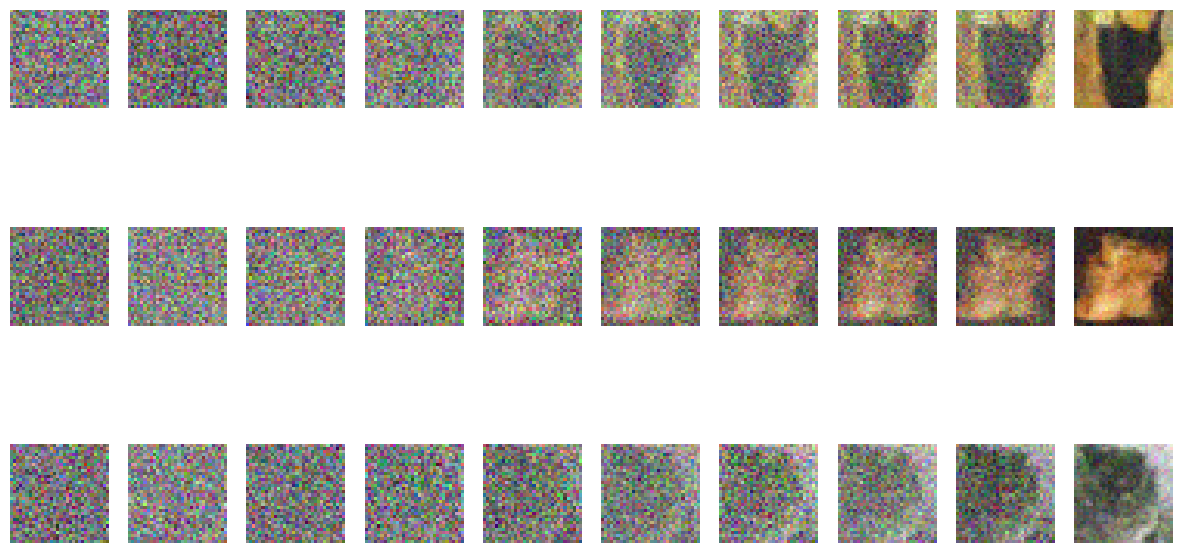

In [11]:
_ = plot_image_evolution_rgb(
    images=synthetic_images_t,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 8),
)